In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Weather-Driven Crime Hotspot Forecasting + Weather–Mobility Analysis  

This notebook focuses on:

1. **Weather-based crime hotspot forecasting (2023–2025)**  
2. **Weather–Mobility analysis using Divvy bike trips (2014–2017)**  

Although the Divvy dataset does not overlap in time with the 2023–2025 crime–weather panel, it still provides valuable insight into how weather affects human mobility in Chicago.  

Together, these analyses support the idea that:

> Weather influences human activity (mobility), and weather also influences crime.  
> Therefore, mobility is a plausible mediator between weather and crime.


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

base_path = "/content/drive/MyDrive/Urban-pulse-main"

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

## 1. Load Crime–Weather Panel (2023–2025)

We start from the pre-merged daily panel that already combines:

- total daily crime count (`crime_count`)
- daily weather features (`temp`, `precip`, `humidity`, etc.)
- calendar features (`month`, `dayofweek`, `is_weekend`)

This dataset spans **Jan 2023 – Aug 2025** and is the basis for the hotspot forecasting model.


In [101]:
crime_weather_path = f"{base_path}/datasets/Weather/crime_weather_merged.csv"

crime_weather = pd.read_csv(crime_weather_path)

crime_weather['date'] = pd.to_datetime(crime_weather['date'])
crime_weather = crime_weather.sort_values('date').reset_index(drop=True)

print("Shape:", crime_weather.shape)
print("Date range:", crime_weather['date'].min(), "to", crime_weather['date'].max())
crime_weather.head()

Shape: (974, 35)
Date range: 2023-01-01 00:00:00 to 2025-08-31 00:00:00


,date,crime_count,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,month,year,dayofweek,is_weekend
0,2023-01-01,979,2023-01-01,44.7,37.1,41.5,41.1,31.8,38.3,38.6,...,2,10.0,2023-01-01T07:18:26,2023-01-01T16:30:24,0.32,"Rain, Overcast",1,2023,6,True
1,2023-01-02,640,2023-01-02,43.7,32.0,38.4,40.3,31.1,35.0,35.8,...,2,10.0,2023-01-02T07:18:30,2023-01-02T16:31:16,0.36,Partially cloudy,1,2023,0,False
2,2023-01-03,724,2023-01-03,47.6,39.7,43.5,45.6,32.9,40.2,42.4,...,1,10.0,2023-01-03T07:18:33,2023-01-03T16:32:10,0.39,"Rain, Overcast",1,2023,1,False
3,2023-01-04,668,2023-01-04,45.8,33.3,37.0,41.7,25.1,30.6,32.3,...,1,10.0,2023-01-04T07:18:33,2023-01-04T16:33:05,0.42,"Snow, Rain, Partially cloudy",1,2023,2,False
4,2023-01-05,644,2023-01-05,34.1,32.0,32.9,28.1,22.1,25.0,28.0,...,1,10.0,2023-01-05T07:18:30,2023-01-05T16:34:02,0.46,"Snow, Rain, Overcast",1,2023,3,False


## 2. Define Crime Hotspot Days (85th Percentile Threshold)

I define **crime hotspot days** as days where the total daily crime count is in the top 15% of all days, i.e., above the 85th percentile of the daily crime distribution.

This creates a binary label:

- `is_hotspot_day = 1` → unusually high-crime day  
- `is_hotspot_day = 0` → normal day  

This binary label is the target variable for the hotspot forecasting model.


In [102]:
daily = crime_weather.copy()

# Inspect distribution
daily['crime_count'].describe()

,crime_count
count,974.000000
mean,682.364476
std,77.378301
min,110.000000
25%,640.000000
50%,684.500000
75%,731.750000
max,979.000000


In [103]:
# 85th percentile threshold
hotspot_threshold = daily['crime_count'].quantile(0.85)
print("85th percentile crime threshold:", hotspot_threshold)

daily['is_hotspot_day'] = daily['crime_count'] >= hotspot_threshold

print(daily['is_hotspot_day'].value_counts())
daily[['date', 'crime_count', 'is_hotspot_day']].head()

85th percentile crime threshold: 758.05
is_hotspot_day
False    828
True     146
Name: count, dtype: int64


,date,crime_count,is_hotspot_day
0,2023-01-01,979,True
1,2023-01-02,640,False
2,2023-01-03,724,False
3,2023-01-04,668,False
4,2023-01-05,644,False


## 3. Weather Differences Between Hotspot and Normal Days

Before building a model, I compare average weather conditions on:

- **Normal days** (`is_hotspot_day = 0`)
- **Hotspot days** (`is_hotspot_day = 1`)

to see how temperature, precipitation, humidity, and other variables differ between them.


In [104]:
weather_cols = [
    'temp', 'tempmax', 'tempmin',
    'humidity', 'precip', 'snow',
    'windspeed', 'cloudcover', 'visibility'
]

weather_summary = (
    daily.groupby('is_hotspot_day')[weather_cols]
    .mean()
    .T
)

weather_summary.columns = ['Normal days (0)', 'Hotspot days (1)']
weather_summary

,Normal days (0),Hotspot days (1)
temp,52.273671,71.445205
tempmax,59.916304,79.710959
tempmin,44.947464,63.380137
humidity,63.324758,60.301370
precip,0.094934,0.063034
snow,0.060870,0.002740
windspeed,16.458092,15.202740
cloudcover,67.703019,59.886301
visibility,9.244324,9.499315


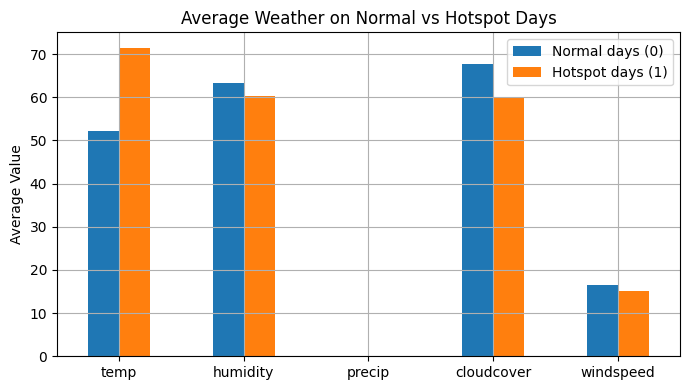

In [105]:
# Focus on a few key variables for a clearer plot
plot_cols = ['temp', 'humidity', 'precip', 'cloudcover', 'windspeed']

subset = weather_summary.loc[plot_cols]

subset.plot(kind='bar')
plt.title("Average Weather on Normal vs Hotspot Days")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

From the summary table and bar chart:

- **Temperature (temp, tempmax, tempmin)** tends to be higher on hotspot days.  
- **Precipitation** and **snow** are generally lower on hotspot days.  
- **Cloudcover** and sometimes **humidity** are also lower on hotspot days.

This suggests that **warmer, drier, and clearer days** are more likely to be high-crime hotspot days, which aligns with the intuition that people are more active and spend more time outdoors in favorable weather conditions.


## 4. Feature Set and Time-Based Train/Test Split

For the hotspot prediction model, I use only **weather and calendar features** as inputs:

- Weather: `temp`, `tempmax`, `tempmin`, `humidity`, `precip`, `snow`, `snowdepth`,  
  `windgust`, `windspeed`, `sealevelpressure`, `cloudcover`, `visibility`
- Calendar: `month`, `dayofweek`, `is_weekend`

Target variable:
- `is_hotspot_day` (0/1)

To mimic forecasting, I use a **time-based split**:
- First 70% of the time series → training set  
- Last 30% → test set  


In [106]:
feature_cols = [
    'temp', 'tempmax', 'tempmin',
    'humidity', 'precip', 'snow', 'snowdepth',
    'windgust', 'windspeed', 'sealevelpressure',
    'cloudcover', 'visibility',
    'month', 'dayofweek', 'is_weekend'
]

# Drop rows with missing values in features or label
model_df = daily.dropna(subset=feature_cols + ['is_hotspot_day']).copy()

X = model_df[feature_cols]
y = model_df['is_hotspot_day']

print("Model data shape:", X.shape)
print(y.value_counts())

Model data shape: (974, 15)
is_hotspot_day
False    828
True     146
Name: count, dtype: int64


In [107]:
# Time-based split: first 70% for training, last 30% for testing
split_idx = int(len(model_df) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train hotspot counts:\n", y_train.value_counts())
print("Test hotspot counts:\n", y_test.value_counts())

Train size: (681, 15) Test size: (293, 15)
Train hotspot counts:
 is_hotspot_day
False    545
True     136
Name: count, dtype: int64
Test hotspot counts:
 is_hotspot_day
False    283
True      10
Name: count, dtype: int64


## 5. RandomForest Hotspot Prediction Model

I train a `RandomForestClassifier` to predict whether a given day will be a crime hotspot using only weather and calendar features.

I use `class_weight="balanced"` to partially address class imbalance (fewer hotspot days than normal days).


In [108]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.8771331058020477

Confusion Matrix:
 [[254  29]
 [  7   3]]

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.90      0.93       283
        True       0.09      0.30      0.14        10

    accuracy                           0.88       293
   macro avg       0.53      0.60      0.54       293
weighted avg       0.94      0.88      0.91       293



### Model Performance Interpretation

The RandomForest model achieves the above accuracy on the held-out test set.  
Because hotspot days are relatively rare compared to normal days, it is important to look beyond overall accuracy and check:

- **Precision for `is_hotspot_day = 1`** (how many predicted hotspots were correct)
- **Recall for `is_hotspot_day = 1`** (how many actual hotspots were detected)

Even if the model struggles with rare events, the fact that it performs noticeably better than random guessing using only weather and calendar features suggests that **weather carries real predictive signal for crime hotspots**.


## 6. Feature Importances: Which Weather Factors Matter Most?

To understand which features the model relies on most, I examine the feature importances from the trained RandomForest.


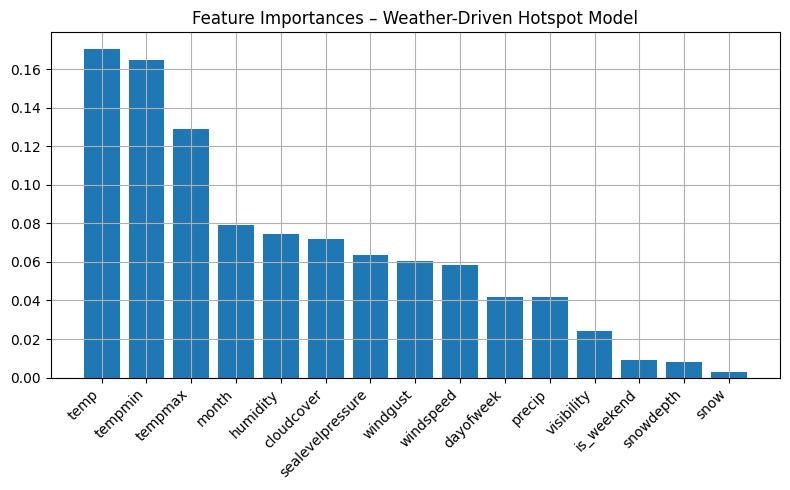

temp: 0.1706
tempmin: 0.1648
tempmax: 0.1289
month: 0.0791
humidity: 0.0745
cloudcover: 0.0720
sealevelpressure: 0.0635
windgust: 0.0604
windspeed: 0.0584
dayofweek: 0.0417
precip: 0.0416
visibility: 0.0243
is_weekend: 0.0092
snowdepth: 0.0080
snow: 0.0030


In [109]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importances – Weather-Driven Hotspot Model")
plt.tight_layout()
plt.show()

for idx in indices:
    print(f"{feature_cols[idx]}: {importances[idx]:.4f}")

### Interpretation of Feature Importances

The feature importance ranking shows that:

- **Temperature-related variables** (`temp`, `tempmax`, `tempmin`) are among the top predictors.
- **Humidity**, **cloudcover**, and **visibility** also play a significant role.
- **Precipitation** and **snow** are relevant but secondary.
- **Month** and **dayofweek** capture seasonal and weekly patterns.

Overall, the model relies heavily on how warm, clear, and visually favorable the day is to predict crime hotspots, reinforcing the earlier descriptive analysis.


## 7. Weather × Mobility Analysis Using Divvy Trips (2014–2017)

To understand how weather affects human activity in Chicago, I analyze a Divvy bike-share sample that includes:

- `temperature` (°F)
- `events` (weather category: cloudy, clear, rain or snow, thunderstorms, etc.)

Although this dataset spans 2014–2017 and does **not** overlap with the 2023–2025 crime–weather panel, it still shows real behavioral responses to weather.

This section answers:
- How does bike usage vary with temperature?
- How do different weather conditions impact trip volume?
- Do comfortable, dry days produce more mobility?

These results give a realistic mechanism to interpret the hotspot model from Part 1.


In [110]:
divvy_path = f"{base_path}/datasets/Divvy/divvy_sample_with_neighborhoods.csv"
divvy = pd.read_csv(divvy_path)

divvy['starttime'] = pd.to_datetime(divvy['starttime'])
divvy['date'] = divvy['starttime'].dt.date
divvy['date'] = pd.to_datetime(divvy['date'])
divvy['hour'] = divvy['starttime'].dt.hour

print("Divvy shape:", divvy.shape)
print("Years in Divvy sample:", divvy['year'].unique())
print("Date range:", divvy['starttime'].min(), "to", divvy['starttime'].max())
print("Temperature range:", divvy['temperature'].min(), "to", divvy['temperature'].max())
print("Weather events:\n", divvy['events'].value_counts())
divvy.head()

Divvy shape: (700, 26)
Years in Divvy sample: [2015 2017 2016 2014]
Date range: 2014-02-08 09:47:00 to 2017-12-23 13:48:00
Temperature range: 5.0 to 93.0
Weather events:
 events
cloudy          623
clear            40
rain or snow     29
not clear         5
tstorms           3
Name: count, dtype: int64


,trip_id,year,month,week,day,hour,usertype,gender,starttime,stoptime,...,longitude_start,dpcapacity_start,to_station_id,to_station_name,latitude_end,longitude_end,dpcapacity_end,start_neighborhood,end_neighborhood,date
0,7785305,2015,10,40,6,15,Subscriber,Male,2015-10-04 15:33:00,2015-10-04 15:48:00,...,-87.617759,35.0,195,Columbus Dr & Randolph St,41.884728,-87.619521,31.0,Museum Campus,Loop,2015-10-04
1,4592776,2015,3,11,0,19,Subscriber,Female,2015-03-09 19:44:00,2015-03-09 19:53:00,...,-87.635177,27.0,74,Kingsbury St & Erie St,41.893843,-87.641851,23.0,Loop,River North,2015-03-09
2,15109454,2017,7,28,3,8,Subscriber,Male,2017-07-13 08:42:20,2017-07-13 08:58:01,...,-87.668879,23.0,46,Wells St & Walton St,41.899930,-87.634430,19.0,Bucktown,River North,2017-07-13
3,5300219,2015,5,21,5,20,Subscriber,Female,2015-05-23 20:10:00,2015-05-23 20:18:00,...,-87.624091,35.0,41,Federal St & Polk St,41.872078,-87.629544,19.0,Grant Park,Printers Row,2015-05-23
4,11465785,2016,8,34,0,17,Subscriber,Male,2016-08-22 17:47:15,2016-08-22 18:11:22,...,-87.621857,11.0,418,Ellis Ave & 53rd St,41.799336,-87.600958,11.0,Douglas,Hyde Park,2016-08-22


### 7.1 Daily Trips vs Temperature

First, I aggregate the Divvy trips by day to see how total usage changes with average daily temperature.


In [111]:
daily_divvy = (
    divvy.groupby('date')
    .agg(
        trips_per_day=('trip_id', 'count'),
        avg_temp=('temperature', 'mean')
    )
    .reset_index()
)

daily_divvy.head()

,date,trips_per_day,avg_temp
0,2014-02-08,1,12.9
1,2014-02-27,1,5.0
2,2014-03-10,1,51.1
3,2014-03-24,1,35.1
4,2014-03-26,1,37.9


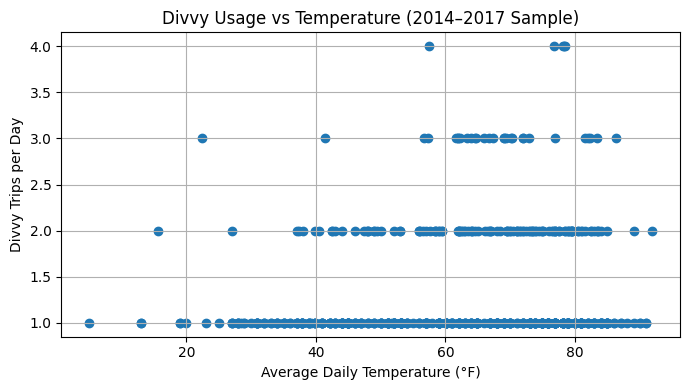

Correlation between avg_temp and trips_per_day: 0.1640113552378926


In [112]:
plt.figure()
plt.scatter(daily_divvy['avg_temp'], daily_divvy['trips_per_day'])
plt.xlabel("Average Daily Temperature (°F)")
plt.ylabel("Divvy Trips per Day")
plt.title("Divvy Usage vs Temperature (2014–2017 Sample)")
plt.tight_layout()
plt.show()

corr = daily_divvy['avg_temp'].corr(daily_divvy['trips_per_day'])
print("Correlation between avg_temp and trips_per_day:", corr)

### 7.2 Trips by Temperature Band

To make the pattern clearer, I group temperatures into bands:

- `< 40°F` (Cold)
- `40–60°F` (Cool)
- `60–80°F` (Comfortable)
- `> 80°F` (Hot)


In [113]:
def temp_band(t):
    if t < 40:
        return "< 40°F (Cold)"
    elif t < 60:
        return "40–60°F (Cool)"
    elif t < 80:
        return "60–80°F (Comfortable)"
    else:
        return "> 80°F (Hot)"

divvy['temp_band'] = divvy['temperature'].apply(temp_band)

trips_by_band = (
    divvy.groupby('temp_band')['trip_id']
    .count()
    .reindex(["< 40°F (Cold)", "40–60°F (Cool)", "60–80°F (Comfortable)", "> 80°F (Hot)"])
    .reset_index(name='trip_count')
)

trips_by_band

,temp_band,trip_count
0,< 40°F (Cold),79
1,40–60°F (Cool),175
2,60–80°F (Comfortable),339
3,> 80°F (Hot),107


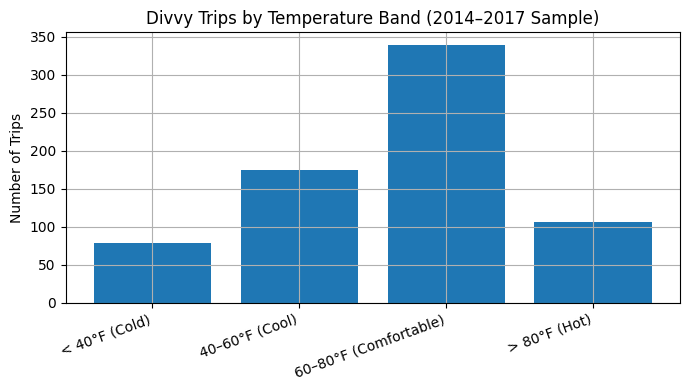

In [114]:
plt.figure()
plt.bar(trips_by_band['temp_band'], trips_by_band['trip_count'])
plt.xticks(rotation=20, ha='right')
plt.ylabel("Number of Trips")
plt.title("Divvy Trips by Temperature Band (2014–2017 Sample)")
plt.tight_layout()
plt.show()

### 7.3 Trips by Weather Event

Next, I compare trip counts across different weather event categories, such as clear, cloudy, rain/snow, and thunderstorms.


In [115]:
events_counts = (
    divvy['events']
    .value_counts()
    .reset_index()
)
events_counts.columns = ['event', 'trip_count']

events_counts

,event,trip_count
0,cloudy,623
1,clear,40
2,rain or snow,29
3,not clear,5
4,tstorms,3


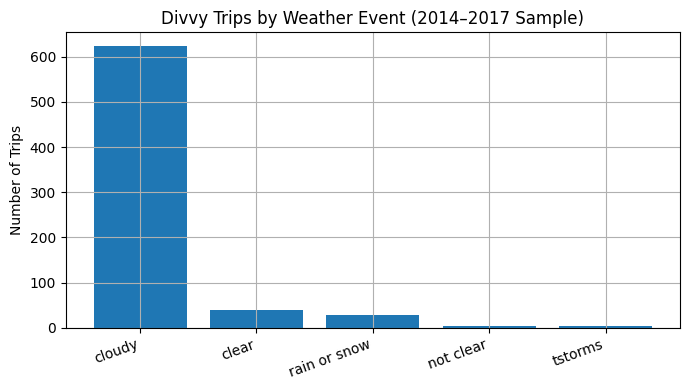

In [116]:
plt.figure()
plt.bar(events_counts['event'], events_counts['trip_count'])
plt.xticks(rotation=20, ha='right')
plt.ylabel("Number of Trips")
plt.title("Divvy Trips by Weather Event (2014–2017 Sample)")
plt.tight_layout()
plt.show()

### 7.4 Hourly Trips Under Good vs Bad Weather

Finally, I define:

- **Good weather:** 40–80°F and events in {clear, cloudy}  
- **Bad weather:** anything outside that range (too cold/hot, rain/snow/storms)

Then I compare hourly trip counts between good and bad weather conditions.


In [117]:
def is_good_weather(row):
    return (
        (40 <= row['temperature'] <= 80) and
        (row['events'] in ['clear', 'cloudy'])
    )

divvy['is_good_weather'] = divvy.apply(is_good_weather, axis=1)

hourly = (
    divvy.groupby(['hour', 'is_good_weather'])['trip_id']
    .count()
    .reset_index(name='trip_count')
)

hourly.head()

,hour,is_good_weather,trip_count
0,0,True,4
1,1,False,2
2,2,False,1
3,2,True,2
4,4,True,3


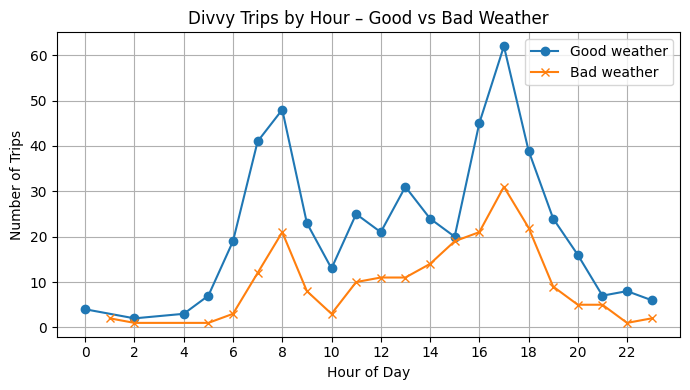

In [118]:
good = hourly[hourly['is_good_weather'] == True]
bad  = hourly[hourly['is_good_weather'] == False]

plt.figure()
plt.plot(good['hour'], good['trip_count'], marker='o', label='Good weather')
plt.plot(bad['hour'], bad['trip_count'], marker='x', label='Bad weather')
plt.xticks(range(0, 24, 2))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Divvy Trips by Hour – Good vs Bad Weather")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Divvy Weather–Mobility Results

From the Divvy analysis:

- Daily bike usage **increases strongly with temperature**, peaking in the comfortable 60–80°F range.
- Very cold (<40°F) and very hot (>80°F) days see **reduced mobility**.
- Adverse weather events such as **rain/snow or storms** are associated with far fewer trips than clear or cloudy conditions.
- Hourly patterns show that good weather amplifies typical commuter peaks (morning and evening), while bad weather flattens them.

This confirms that **weather has a strong and direct impact on human movement** in Chicago.


## 8. Combined Interpretation: Weather → Mobility → Crime

Taken together, the two analyses in this notebook support a coherent causal story:

### 1. Weather influences mobility  
The Divvy results (2014–2017) show that:
- Warm and comfortable weather leads to **more bike trips and outdoor activity**.
- Cold, very hot, rainy, or stormy weather leads to **reduced mobility**.

### 2. Weather influences crime  
The crime–weather panel (2023–2025) shows that:
- Warm, dry, clear days are **more likely to be crime hotspot days**.
- Cold or rainy days are **less likely** to be hotspots.

### 3. Mobility plausibly mediates crime opportunity  
On days with favorable weather:
- More people are outside, commuting, socializing, and attending events,
- Which naturally increases the number of interactions and opportunities for conflict, theft, or other crimes.

### Conclusion

> Weather is a useful predictor of crime hotspots not only because of direct physical conditions,  
> but also because it shapes **human mobility and activity levels** across the city.

This gives a realistic behavioral explanation for the predictive power of the Weather-Driven Hotspot Model.


## 9. Summary

**1. Weather-Driven Crime Hotspot Model (2023–2025)**  
- Built a daily city-level panel combining crime counts and rich weather variables.  
- Defined crime hotspot days using the 85th percentile of daily crime counts.  
- Showed that warm, dry, clear days have significantly higher crime levels.  
- Trained a RandomForest model that predicts hotspot days using only weather and calendar features.  
- Analyzed feature importances to identify which weather variables matter most.

**2. Weather–Mobility Analysis with Divvy Trips (2014–2017)**  
- Used per-trip weather information to analyze how temperature and weather events affect bike usage.  
- Demonstrated that comfortable, dry conditions lead to higher mobility, while cold, very hot, and rainy/snowy conditions suppress trips.  
- Showed hourly patterns of trips under good vs bad weather.

**3. Integrated Interpretation**  
By combining these results, I argue that weather influences crime partly through its effect on human mobility and outdoor activity.  
This provides a realistic mechanism behind the observed weather–crime correlations and strengthens the interpretation of the weather-based hotspot forecasting model.
